In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
sp_500_df = pd.read_csv("../../data/raw/processed_sp_500_macro_data.csv", index_col='Date', parse_dates=True)
display(sp_500_df)

,_VA_LogRet,Vol_5d,3M_Interest_Rate_Change,_MKT_LogRet,Synthetic_Bond_Return,_TY_LogRet,Copper_Gold_Trend_3M,_DXY_LogRet,_GR_LogRet,Close_LogRet_Lag2,...,Close_LogRet_Lag3,RR_Volatility_13W,NYF_ZScore_1Y,Y10,Inflation_Proxy,CAPE_Yield,RR_Momentum_1Y,Return_5d,_DXY,Target_Return_5D
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-07,-0.010646,0.016700,0.038,-0.007813,0.001265,0.002018,-0.002151,0.012258,-0.003296,-0.005489,...,0.012890,0.026866,-0.230410,3.572,2.129,5.907372,0.014,-0.007177,80.440,-0.002745
2010-02-14,0.004924,0.013587,0.035,0.012001,-0.009582,-0.009071,0.062051,-0.001493,0.015860,-0.002235,...,0.012956,0.028462,-0.187613,3.694,2.131,5.838393,-0.163,0.008703,80.320,-0.001046
2010-02-21,0.032371,0.008263,0.087,0.031615,-0.006610,-0.006255,0.108292,0.003976,0.030241,0.004229,...,0.017841,0.033829,-0.552519,3.778,2.106,5.658669,-0.127,0.028069,80.640,0.001405
2010-02-28,-0.002970,0.007745,0.094,-0.002872,0.013137,0.014368,0.118424,-0.003478,-0.005522,0.009674,...,-0.012177,0.037111,-0.544068,3.613,2.121,5.676658,-0.127,-0.004228,80.360,0.014007
2010-03-07,0.029278,0.005743,0.099,0.031297,-0.005512,-0.005153,0.136076,0.000871,0.031878,0.000429,...,0.002328,0.038838,-0.555477,3.683,2.151,5.526083,-0.127,0.030504,80.430,-0.000217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-05,0.026386,0.016222,0.073,0.033367,0.006901,0.008174,-0.091182,0.000679,0.041609,0.028715,...,-0.003954,0.018747,-1.016643,4.345,3.120,2.824061,-0.656,0.016161,100.219,-0.001139
2026-04-12,0.026733,0.010884,0.082,0.033503,0.001819,0.002583,-0.074295,-0.015780,0.042676,0.024772,...,0.000759,0.017029,-0.978393,4.322,3.104,2.734332,-0.656,0.034960,98.650,0.012040
2026-04-19,0.025162,0.006802,0.046,0.045743,0.006264,0.007088,-0.025544,-0.005611,0.066923,0.007944,...,0.011714,0.015750,-0.927499,4.243,3.114,2.615336,-0.670,0.044355,98.098,0.007974


In [3]:
""" Split data """
target_col = 'Target_Return_5D'

y = sp_500_df[target_col]
X = sp_500_df.drop(columns=[target_col])

# Train/test split (80% train, 20% test) without shuffling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

# Check the split
print(f"Total dataset size: {len(sp_500_df)} rows")
print("-" * 40)
print(f"Training set (X_train): {X_train.shape[0]} rows | {X_train.shape[1]} features")
print(f"Testing set  (X_test):  {X_test.shape[0]} rows | {X_test.shape[1]} features")
print("-" * 40)

# Print the date ranges to prove there is no data leakage
print(f"Training Dates: {X_train.index.min().strftime('%Y-%m-%d')} to {X_train.index.max().strftime('%Y-%m-%d')}")
print(f"Testing Dates:  {X_test.index.min().strftime('%Y-%m-%d')} to {X_test.index.max().strftime('%Y-%m-%d')}")

Total dataset size: 848 rows
----------------------------------------
Training set (X_train): 678 rows | 20 features
Testing set  (X_test):  170 rows | 20 features
----------------------------------------
Training Dates: 2010-02-07 to 2023-01-29
Testing Dates:  2023-02-05 to 2026-05-03


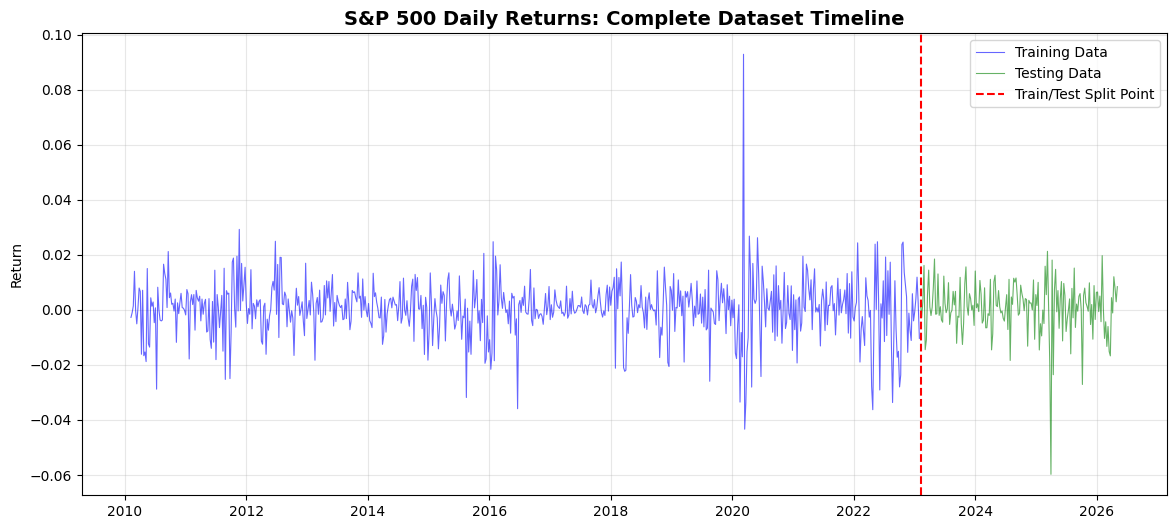

In [4]:
# Plot dataset
plt.figure(figsize=(14, 6))

# Plot training portion
plt.plot(y_train.index, y_train.values, color='blue', alpha=0.6, linewidth=0.8, label='Training Data')
# Plot testing portion
plt.plot(y_test.index, y_test.values, color='green', alpha=0.6, linewidth=0.8, label='Testing Data')

plt.axvline(x=y_test.index.min(), color='red', linestyle='--', label='Train/Test Split Point')
plt.title('S&P 500 Daily Returns: Complete Dataset Timeline', fontsize=14, fontweight='bold')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Baselines

### SARIMAX

Training SARIMAX baseline model over multiple seeds (this may take a moment)...

--- Training with seed 42 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


MSE: 0.000212 | MAE: 0.012157 | Dir. Acc: 47.06%

--- Training with seed 99 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


MSE: 0.000212 | MAE: 0.012157 | Dir. Acc: 47.06%

--- Training with seed 123 ---
MSE: 0.000212 | MAE: 0.012157 | Dir. Acc: 47.06%

Training Complete!

Generating Plot...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


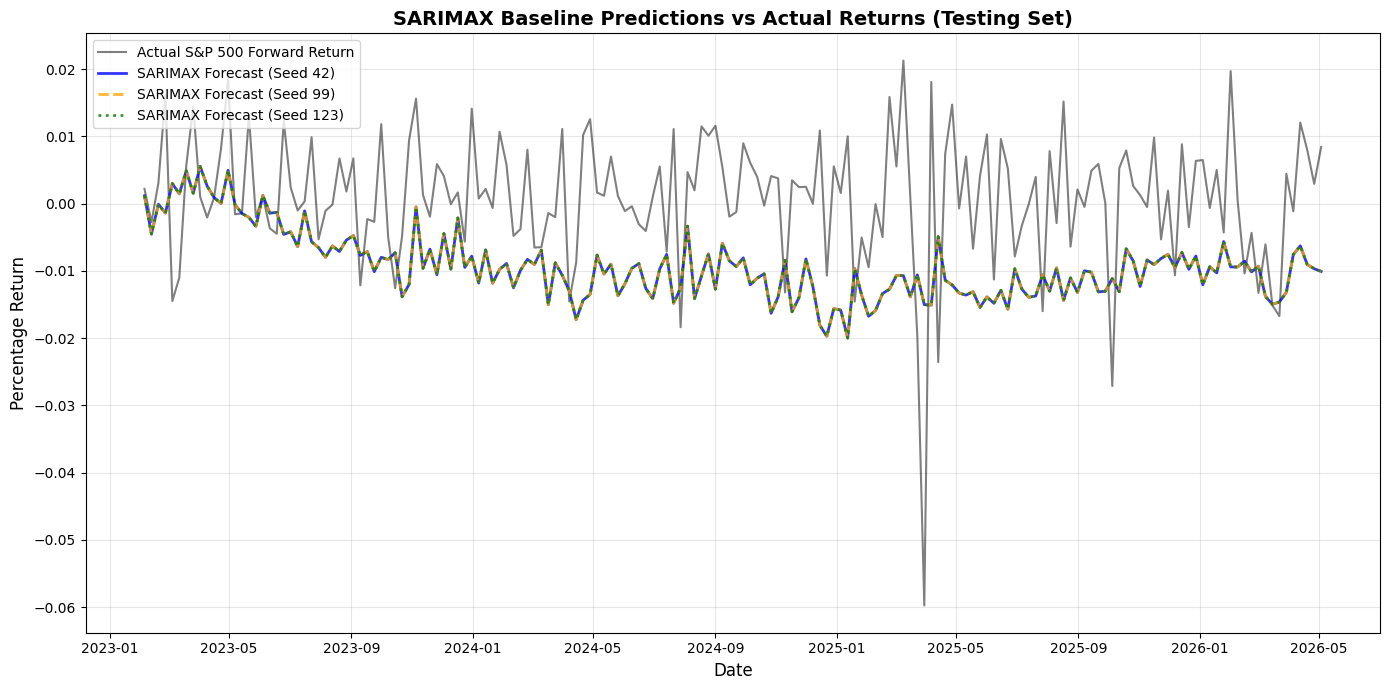

In [5]:
# SARIMAX Baseline
print("Training SARIMAX baseline model over multiple seeds (this may take a moment)...")

seeds = [42, 99, 123]
predictions_dict = {}

for seed in seeds:
    print(f"\n--- Training with seed {seed} ---")
    # Setting the numpy seed ensures maximum reproducibility if the optimizer 
    # ever falls back to random starts (though SARIMAX is largely deterministic)
    np.random.seed(seed)
    
    # order=(1, 0, 1) represents AR(1), I(0), MA(1). 
    # We use I=0 because daily percentage returns are already stationary.
    # Exogenous variables (exog) allow the model to use your engineered features.
    baseline_model = SARIMAX(
        endog=y_train, 
        exog=X_train, 
        order=(1, 0, 1), 
        enforce_stationarity=False, 
        enforce_invertibility=False
    )

    baseline_results = baseline_model.fit(disp=False)
    
    # Forecast into the testing period using the test set's macro features
    preds = baseline_results.forecast(steps=len(y_test), exog=X_test)
    predictions_dict[seed] = preds
    
    # Calculate error metrics
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    directional_accuracy = (np.sign(preds) == np.sign(y_test)).mean() * 100
    
    print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Dir. Acc: {directional_accuracy:.2f}%")

print("\nTraining Complete!\n")

# ====================================================================
# 6. PLOT THE RESULTS
# ====================================================================
print("Generating Plot...")
plt.figure(figsize=(14, 7))

# Plot actual test values
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Forward Return', 
         color='black', alpha=0.5, linewidth=1.5)

# Plot predictions for each seed
colors = ['blue', 'orange', 'green']
line_styles = ['-', '--', ':']

for i, seed in enumerate(seeds):
    # Note: Since SARIMAX is deterministic, these lines will perfectly overlap.
    # We use different line styles to make it visible if there are any minute deviations.
    plt.plot(y_test.index, predictions_dict[seed], label=f'SARIMAX Forecast (Seed {seed})', 
             color=colors[i], linestyle=line_styles[i], alpha=0.8, linewidth=2)

plt.title('SARIMAX Baseline Predictions vs Actual Returns (Testing Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percentage Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression


--- Training with seed 42 ---
MSE: 0.000117 | MAE: 0.008307 | Dir. Acc: 50.00%

--- Training with seed 99 ---
MSE: 0.000117 | MAE: 0.008307 | Dir. Acc: 50.00%

--- Training with seed 123 ---
MSE: 0.000117 | MAE: 0.008307 | Dir. Acc: 50.00%

Training Complete!

Generating Plot...


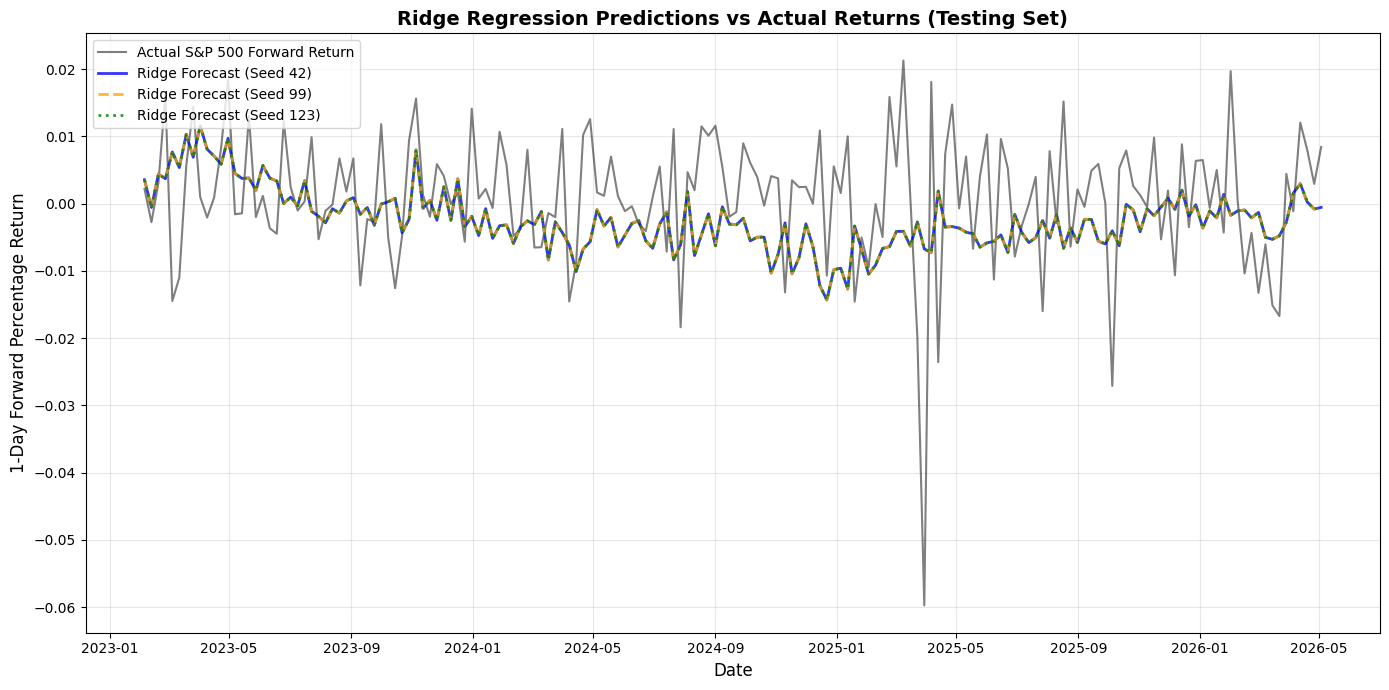

In [6]:
# BASELINE MODEL: RIDGE REGRESSION
seeds = [42, 99, 123]
predictions_dict = {}

for seed in seeds:
    print(f"\n--- Training with seed {seed} ---")
    
    # Initialize Ridge Regression (alpha=1.0 is the standard regularization strength)
    baseline_model = Ridge(alpha=1.0, random_state=seed)
    baseline_model.fit(X_train_scaled, y_train)
    
    # Predict on the scaled testing set
    preds = baseline_model.predict(X_test_scaled)
    
    # Convert numpy array back to Pandas Series with correct dates for easy evaluation
    preds_series = pd.Series(preds, index=y_test.index)
    predictions_dict[seed] = preds_series
    
    # Calculate error metrics
    mse = mean_squared_error(y_test, preds_series)
    mae = mean_absolute_error(y_test, preds_series)
    directional_accuracy = (np.sign(preds_series) == np.sign(y_test)).mean() * 100
    
    print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Dir. Acc: {directional_accuracy:.2f}%")

print("\nTraining Complete!\n")

# Plot Results
print("Generating Plot...")
plt.figure(figsize=(14, 7))

# Plot actual test values
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Forward Return', 
         color='black', alpha=0.5, linewidth=1.5)

# Plot predictions for each seed
colors = ['blue', 'orange', 'green']
line_styles = ['-', '--', ':']

for i, seed in enumerate(seeds):
    # Standard Ridge Regression has a closed-form mathematical solution, 
    # so these lines will still perfectly overlap regardless of the seed.
    plt.plot(y_test.index, predictions_dict[seed], label=f'Ridge Forecast (Seed {seed})', 
             color=colors[i], linestyle=line_styles[i], alpha=0.8, linewidth=2)

plt.title('Ridge Regression Predictions vs Actual Returns (Testing Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('1-Day Forward Percentage Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Linear Regression

MSE: 0.000112 | MAE: 0.008036 | Dir. Acc: 53.53%

Training Complete!

Generating Testing Set Prediction Plot...


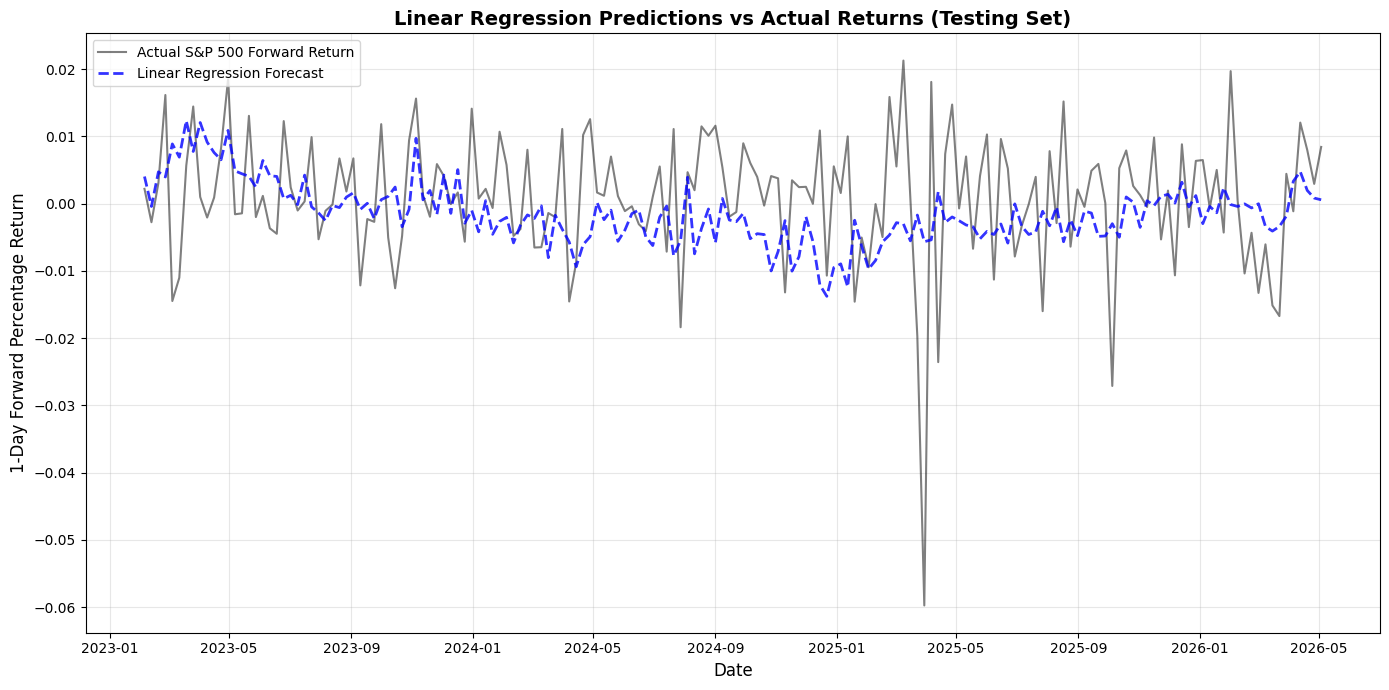

In [7]:
# Linear Regression Baseline
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Predict on the scaled testing set
preds = baseline_model.predict(X_test_scaled)
preds_series = pd.Series(preds, index=y_test.index)

# Calculate error metrics
mse = mean_squared_error(y_test, preds_series)
mae = mean_absolute_error(y_test, preds_series)
directional_accuracy = (np.sign(preds_series) == np.sign(y_test)).mean() * 100

print(f"MSE: {mse:.6f} | MAE: {mae:.6f} | Dir. Acc: {directional_accuracy:.2f}%")
print("\nTraining Complete!\n")

# Plot Results
print("Generating Testing Set Prediction Plot...")
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual S&P 500 Forward Return', color='black', alpha=0.5, linewidth=1.5)

# Plot predictions
plt.plot(y_test.index, preds_series, label='Linear Regression Forecast', 
         color='blue', linestyle='--', alpha=0.8, linewidth=2)

plt.title('Linear Regression Predictions vs Actual Returns (Testing Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('1-Day Forward Percentage Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()